# Taller 2 #


In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd 

In [3]:
df= pd.read_csv("Datos.csv")
sns.set_style('darkgrid')
df.describe

<bound method NDFrame.describe of          Country                           Region  Happiness Rank  \
0    Switzerland                   Western Europe               1   
1        Iceland                   Western Europe               2   
2        Denmark                   Western Europe               3   
3         Norway                   Western Europe               4   
4         Canada                    North America               5   
..           ...                              ...             ...   
153       Rwanda               Sub-Saharan Africa             154   
154        Benin               Sub-Saharan Africa             155   
155        Syria  Middle East and Northern Africa             156   
156      Burundi               Sub-Saharan Africa             157   
157         Togo               Sub-Saharan Africa             158   

     Happiness Score  Standard Error  Economy (GDP per Capita)   Family  \
0              7.587         0.03411                   1.39651

In [4]:
# Correlacion ingreso vs felicidad 

r1=df[["Economy (GDP per Capita)", "Happiness Score"]].corr()
print(f"La relacion entre el ingreso per capita y la felicidad de los habitantes de un pais es positiva y de intensidad: {r1.iloc[0,1].round(2)}")


La relacion entre el ingreso per capita y la felicidad de los habitantes de un pais es positiva y de intensidad: 0.78


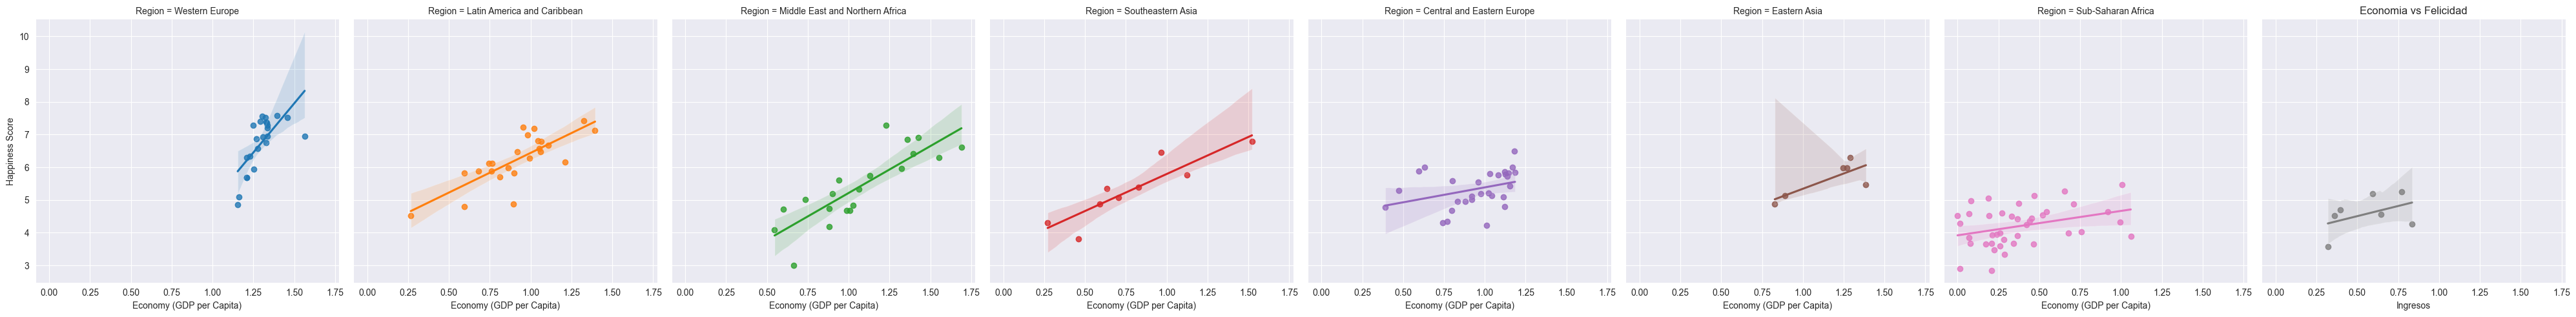

In [5]:
#Grafico asociado

mapa_region = {
    "North America": "Latin America and Caribbean",
    "Australia and New Zealand": "Western Europe"
}

# Reemplazar los valores en la columna "Region"
df["Region"] = df["Region"].replace(mapa_region)

sns.lmplot(data=df, x='Economy (GDP per Capita)', y='Happiness Score', hue="Region", col="Region")
plt.title("Economia vs Felicidad")
plt.xlabel("Ingresos")
plt.ylabel("Indice de felicidad")
plt.show()


What: Gráfico de dispersión con regresión lineal por región, que relaciona el PIB per cápita (Economy (GDP per Capita)) con el Happiness Score. Cada subgráfico corresponde a una región, y los puntos están coloreados por la misma categoría.

Why: Permite observar la relación entre ingresos y felicidad en distintas regiones, identificando si el patrón es consistente o varía según el contexto geográfico-cultural. Es útil para detectar regiones donde el ingreso tiene un impacto más o menos pronunciado en la felicidad.

Who: Dirigido a analistas socioeconómicos, investigadores en bienestar y responsables de políticas públicas que quieran entender cómo la prosperidad económica se traduce (o no) en bienestar subjetivo según la región.

In [6]:
# Happiness Score por region

r3= df.groupby("Region")["Happiness Score"].mean()
r3= r3.round(2)
r3=r3.reset_index()
r3

,Region,Happiness Score
0,Central and Eastern Europe,5.33
1,Eastern Asia,5.63
2,Latin America and Caribbean,6.24
3,Middle East and Northern Africa,5.41
4,Southeastern Asia,5.32
5,Southern Asia,4.58
6,Sub-Saharan Africa,4.20
7,Western Europe,6.74


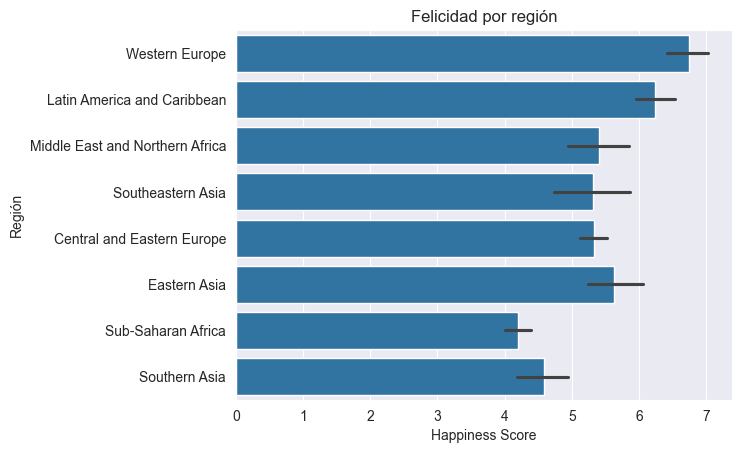

In [7]:
sns.barplot(data=df, x="Happiness Score", y="Region")
plt.title("Felicidad por región")
plt.xlabel("Happiness Score")
plt.ylabel("Región")
plt.show()

What: Gráfico de barras horizontales que muestra el promedio del Happiness Score por región.

Why: Facilita la comparación directa entre regiones, destacando cuáles presentan mayores niveles de felicidad promedio y cuáles se encuentran rezagadas. Es una visión agregada y clara para priorizar análisis más profundos.

Who: Ideal para tomadores de decisiones, ONGs y organismos internacionales que buscan identificar regiones con mayor o menor bienestar para orientar recursos y programas.

In [8]:
#5_ Acumulación de felicidad

r5= df.groupby("Happiness Score")["Country"].sum()
r5= r5.round(2)
r5= r5.reset_index()
r5

,Happiness Score,Country
0,2.839,Togo
1,2.905,Burundi
2,3.006,Syria
3,3.340,Benin
4,3.465,Rwanda
...,...,...
152,7.427,Canada
153,7.522,Norway
154,7.527,Denmark
155,7.561,Iceland


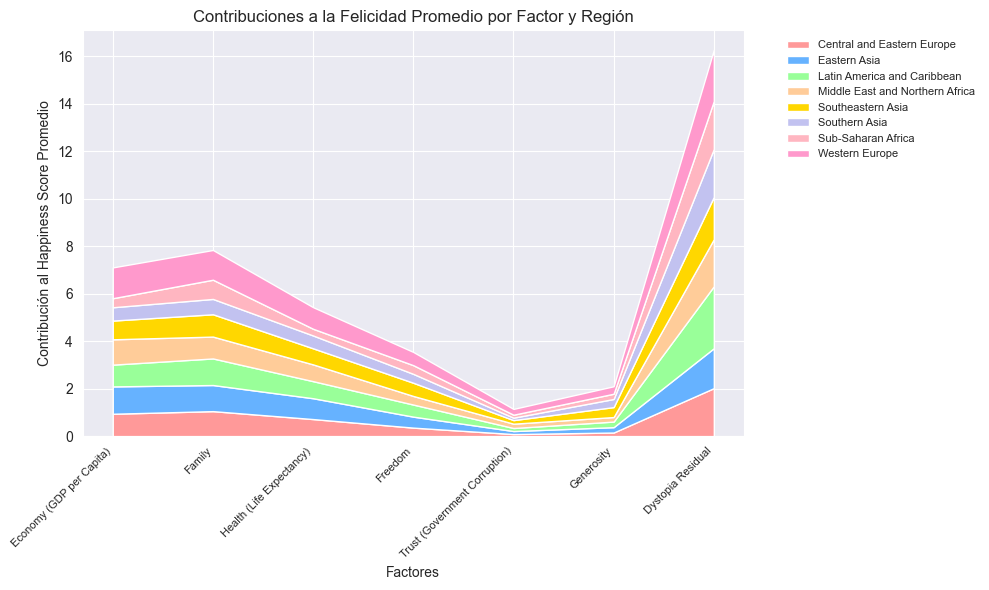

In [9]:

# Suponiendo que df ya está cargado desde "Datos.csv"
# Aplicar el mapeo de regiones
mapa_region = {
    "North America": "Latin America and Caribbean",
    "Australia and New Zealand": "Western Europe"
}
df["Region"] = df["Region"].replace(mapa_region)

# Agrupar por región y calcular el promedio de los factores
region_data = df.groupby('Region')[['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
                                   'Freedom', 'Trust (Government Corruption)', 'Generosity', 
                                   'Dystopia Residual']].mean().reset_index()

# Factores para el eje x
factors = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
           'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

# Extraer valores por región
regions = region_data['Region']
values = [region_data[f].values for f in factors]

# Transponer los datos para que las regiones se apilen por factor
stacked_values = list(zip(*values))

# Crear un solo stackplot
plt.figure(figsize=(10, 6))
plt.stackplot(factors, stacked_values, labels=regions, 
              colors=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#C2C2F0', '#FFB6C1', '#FF99CC'])

plt.title("Contribuciones a la Felicidad Promedio por Factor y Región", fontsize=12)
plt.xlabel("Factores", fontsize=10)
plt.ylabel("Contribución al Happiness Score Promedio", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

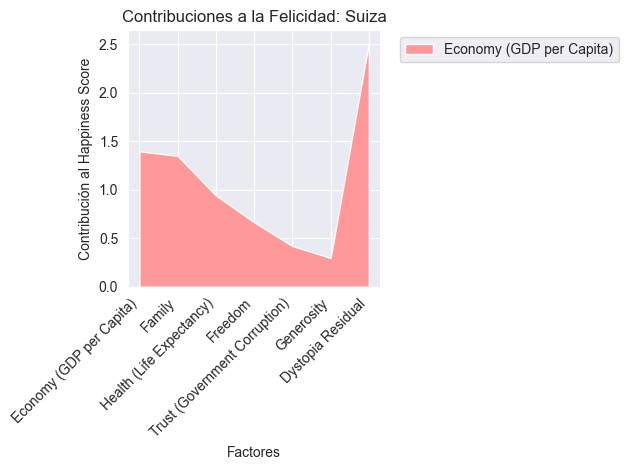

In [10]:

# Filtrar datos para Switzerland (rank 1) como ejemplo
country_data = df[df['Country'] == 'Switzerland'].iloc[0]

# Datos de los factores
factors = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
           'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
values = [country_data[f] for f in factors]

# Etiquetas para el eje x
x_labels = range(len(factors))

# Crear el stackplot
plt.stackplot(x_labels, values, labels=factors, colors=['#FF9999', '#66B2FF', '#99FF99', 
                                                        '#FFCC99', '#FFD700', '#C2C2F0', '#FFB6C1'])

plt.title("Contribuciones a la Felicidad: Suiza")
plt.xlabel("Factores")
plt.ylabel("Contribución al Happiness Score")
plt.xticks(x_labels, factors, rotation=45, ha='right')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

What: Gráfico de área apilada que representa la contribución de cada factor (Economía, Familia, Salud, Libertad, Confianza, Generosidad, Dystopia Residual) al Happiness Score de Suiza.

Why: Permite descomponer el puntaje total en sus componentes, mostrando qué factores son más determinantes en el caso de un país específico. En Suiza, por ejemplo, se puede ver el peso relativo de la economía y la salud.

Who: Útil para investigadores y gobiernos que quieran entender la “receta” de la felicidad en países líderes y compararla con otros contextos.

In [11]:
#7_  Ficción: regiones vs. tiempo

r7= df.groupby("Health (Life Expectancy)")["Economy (GDP per Capita)"].mean()
r7= r7.round(2)
r7= r7.reset_index()
r7


,Health (Life Expectancy),Economy (GDP per Capita)
0,0.00000,0.33
1,0.04776,0.99
2,0.06699,0.08
3,0.07566,0.71
4,0.07612,0.38
...,...,...
152,0.95562,1.23
153,0.96538,1.24
154,0.99111,1.27
155,1.01328,1.39


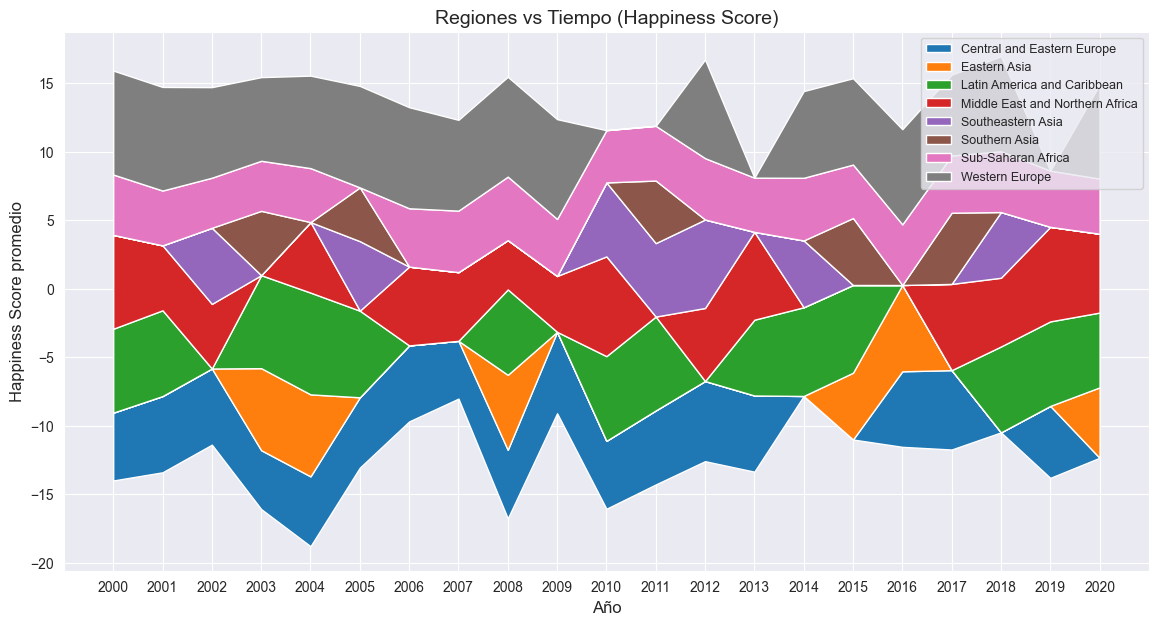

In [12]:
years = np.tile(np.arange(2000, 2021), len(df) // 21 + 1)[:len(df)]
df["Year"] = years

# --- Paso 2: Agrupar datos por Año y Región ---
# Ejemplo con Happiness Score (puedes cambiarlo a otra columna si quieres)
df_grouped = df.groupby(["Year", "Region"])["Happiness Score"].mean().reset_index()

# --- Paso 3: Reorganizar datos para stackplot ---
pivot = df_grouped.pivot(index="Year", columns="Region", values="Happiness Score").fillna(0)

# Eje X = años
x = pivot.index
# Eje Y = valores de cada región
ys = pivot.T.values

# --- Paso 4: Graficar Streamgraph ---
fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(x, ys, labels=pivot.columns, baseline='wiggle')
ax.set_xticks(range(2000, 2021))
ax.set_xticklabels(range(2000, 2021))
ax.legend(loc='upper right', fontsize=9)
ax.set_title("Regiones vs Tiempo (Happiness Score)", fontsize=14)
ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Happiness Score promedio", fontsize=12)

plt.show()



What: Gráfico de áreas apiladas con baseline “wiggle” que muestra la evolución del Happiness Score promedio por región entre 2000 y 2020.

Why: Visualiza tendencias temporales y cambios en la distribución del bienestar entre regiones. El formato tipo streamgraph enfatiza la dinámica y la variabilidad a lo largo del tiempo.

Who: Pensado para analistas de tendencias globales, economistas y sociólogos que estudian la evolución del bienestar y su relación con eventos históricos o políticas regionales

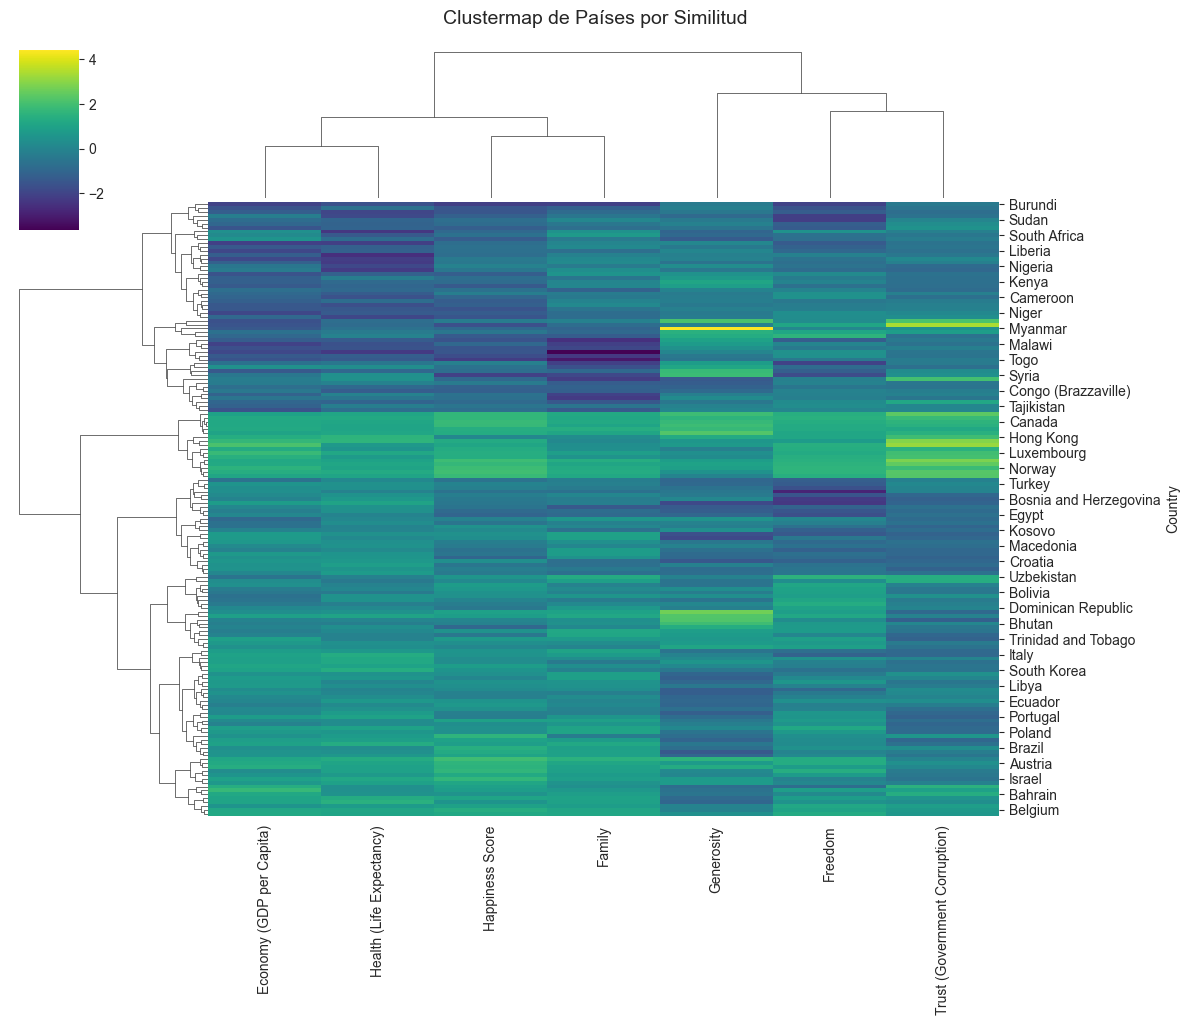

In [14]:
from sklearn.preprocessing import StandardScaler  

features = [
    "Happiness Score",
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity"
]

# Filtrar el dataframe
X = df[features]

# Escalar los datos (Z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Crear un DataFrame con países como índice
X_df = pd.DataFrame(X_scaled, index=df["Country"], columns=features)

# Crear el clustermap
sns.clustermap(
    X_df,
    method="ward",        
    metric="euclidean",   
    cmap="viridis",
    figsize=(12, 10)
)

plt.suptitle("Clustermap de Países por Similitud", fontsize=14, y=1.02)
plt.show()




What: Mapa de calor con dendrogramas que agrupa países según la similitud de sus valores en Happiness Score y factores asociados, usando distancia euclidiana y método de enlace Ward.

Why: Permite identificar grupos de países con perfiles de felicidad y factores similares, lo que puede sugerir patrones culturales, económicos o políticos comunes.

Who: Dirigido a investigadores en análisis multivariado, consultores y organismos internacionales que buscan segmentar países para estudios comparativos o estrategias conjuntas.

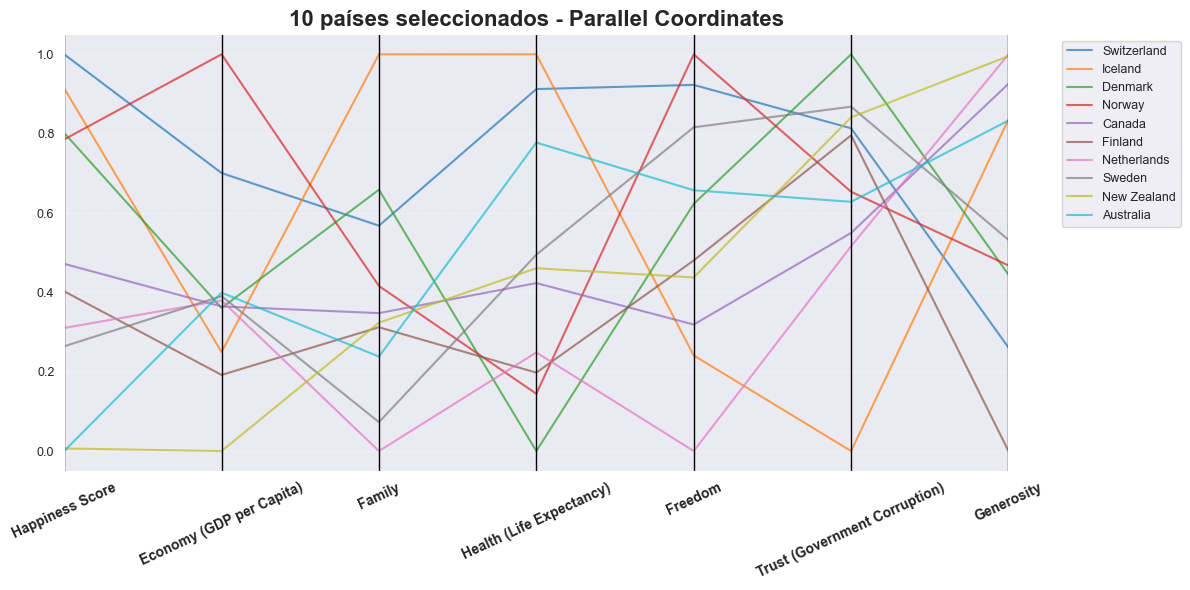

In [ ]:
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler


paises = ["Switzerland", "Iceland", "Denmark", "Norway", "Canada",
          "Finland", "Netherlands", "Sweden", "New Zealand", "Australia"]
df_sel = df[df["Country"].isin(paises)]

# Variables a usar
factores = [
    "Happiness Score",
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity"
]

# Normalización
scaler = MinMaxScaler()
df_norm = df_sel.copy()
df_norm[factores] = scaler.fit_transform(df_sel[factores])

# Añadir columna de país como clase
df_norm = df_norm[["Country"] + factores]

# === Gráfico mejorado ===
plt.figure(figsize=(12, 6))
parallel_coordinates(
    df_norm,
    class_column="Country",
    cols=factores,
    color=plt.cm.tab10.colors,
    alpha=0.7,
    linewidth=1.5
)

# Estética
plt.title("10 países seleccionados - Parallel Coordinates", fontsize=16, fontweight='bold')
plt.xticks(rotation=25, fontsize=10, fontweight='bold')
plt.ylabel="Puntuación"
plt.yticks(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


What: Gráfico de coordenadas paralelas que muestra simultáneamente los valores normalizados de varios factores para 10 países con alto Happiness Score.

Why: Facilita la comparación multivariada, permitiendo ver en qué dimensiones cada país destaca o queda rezagado respecto a sus pares.

Who: Útil para analistas comparativos, académicos y responsables de políticas que quieran identificar fortalezas y debilidades relativas en países de alto bienestar

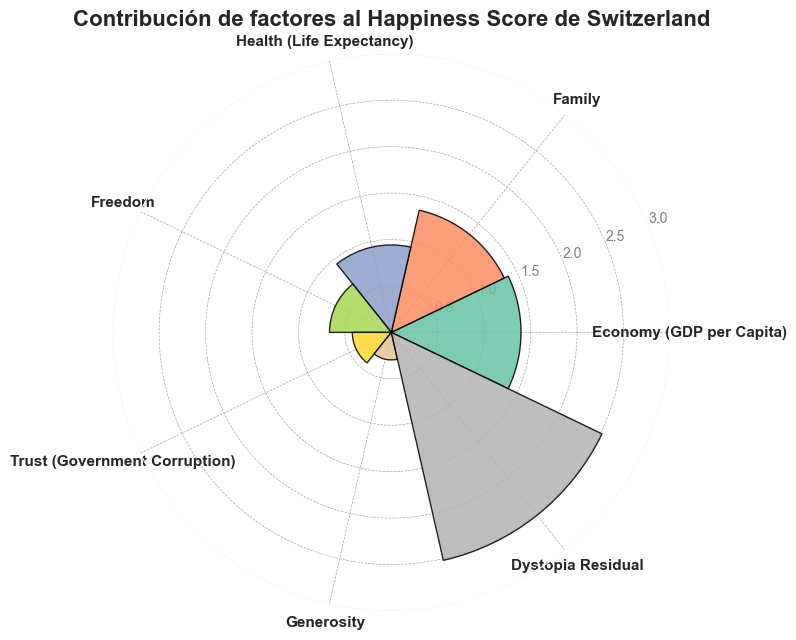

In [ ]:
pais = "Switzerland"  # Puedes cambiarlo por cualquier país del CSV
row = df[df["Country"] == pais].iloc[0]

# === 3. Factores a graficar ===
factores = [
    "Economy (GDP per Capita)",
    "Family",
    "Health (Life Expectancy)",
    "Freedom",
    "Trust (Government Corruption)",
    "Generosity",
    "Dystopia Residual"
]

valores = row[factores].values

# === 4. Configuración de ángulos ===
N = len(factores)
angulos = np.linspace(0, 2 * np.pi, N, endpoint=False)

# === 5. Crear gráfico polar mejorado ===
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 8))

# Barras radiales con colores contrastados
bars = ax.bar(
    angulos,
    valores,
    width=2*np.pi/N,
    bottom=0,
    color=plt.cm.Set2(np.linspace(0, 1, N)),
    edgecolor='black',
    alpha=0.85
)

# === 6. Estética y visibilidad ===
ax.set_facecolor('white')  # Fondo claro
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)  # Cuadrícula suave

# Etiquetas de los factores
ax.set_xticks(angulos)
ax.set_xticklabels(factores, fontsize=11, fontweight='bold')

# Escala radial
max_val = max(valores) + 0.5
ax.set_yticks(np.arange(0.5, max_val, 0.5))
ax.set_yticklabels([f"{y:.1f}" for y in np.arange(0.5, max_val, 0.5)],
                   fontsize=10, color='gray')

# Título
ax.set_title(f"Contribución de factores al Happiness Score de {pais}",
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()



What: Gráfico polar de barras que representa la magnitud de cada factor que contribuye al Happiness Score de Suiza.

Why: Ofrece una visión radial que facilita la comparación angular y radial de los factores, destacando visualmente cuáles son más influyentes.

Who: Pensado para presentaciones ejecutivas, informes visuales y análisis rápidos donde se quiera mostrar de forma atractiva y clara el perfil de un país en términos de felicidad.